# 08 · Методи та результати — емпіричний корректор EGG2015→EVRF2019

Науковий документ по Фазі 2c. Уся арифметика читається з
`outputs/tables/egg2015_to_evrf2019_*.csv`; проза будується з тих самих таблиць.

## Що саме оцінюється

$$c_i \;=\; H_{\mathrm{gauge},\,EVRF2019} \;-\; H_{\mathrm{ICESat},\,EGG2015}$$

$$H_{\mathrm{ICESat},\,EGG2015} \;=\; h_{\mathrm{ATL13}} - \zeta_{\mathrm{EGG2015}}
\qquad
H_{\mathrm{gauge},\,EVRF2019} \;=\; 12.00 + \mathrm{stage} + \Delta_{9902}(\varphi,\lambda)$$

**Три різні твердження — не плутати:**

1. *виміряне:* $c_i = H_{\text{gauge},EVRF2019} - H_{\text{ICESat},EGG2015}$;
2. *емпіричне застосування:* $H_{\text{ATL13},EVRF2019}^{\text{emp}} = H_{\text{ATL13},EGG2015} + c(x,y)$;
3. *занадто сильно (НЕ робимо):* $\zeta_{EVRF2019} = \zeta_{EGG2015} - c$ — це вимагало б,
   щоб залишок був суто квазігеоїдною різницею; ці дані не відділяють його від
   спільного зсуву ATL13 та інших приладових членів. **Не квазігеоїд.**

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)

from kakhovka_altimetry.config import load_config
cfg = load_config()
TABLES = cfg.tables_dir
FIGS = cfg.repo_root / "outputs" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)

by_station = pd.read_csv(TABLES / "egg2015_to_evrf2019_by_station.csv")
by_radius  = pd.read_csv(TABLES / "egg2015_to_evrf2019_by_radius.csv")
by_rgt     = pd.read_csv(TABLES / "egg2015_to_evrf2019_by_rgt.csv")
unc        = pd.read_csv(TABLES / "egg2015_to_evrf2019_uncertainty.csv")
matchups   = pd.read_csv(TABLES / "gauge_icesat_egg2015_matchups.csv", parse_dates=["datetime"])
# EPSG:9902 operation-accuracy field. NOT a sigma, NOT a 95% CI: the same EPSG
# record separately reports SD 0.034 m over its 154 determination points.
EPSG9902_OP_ACC = 0.068
EPSG9902_SD_154 = 0.034

## Executive summary (будується з таблиць)

In [2]:
c = by_station.loc[np.isfinite(by_station["c_station_m"]), "c_station_m"].to_numpy()
nmad_stations = 1.4826 * np.median(np.abs(c - np.median(c)))
pass_nmad = by_station["empirical_nmad_m"].dropna()
lines = [
    f"Гідропостів з корректором: {len(c)} з 6.",
    f"c_station: {c.min():+.3f} … {c.max():+.3f} м, медіана {np.median(c):+.3f} м.",
    f"Станція-до-станції NMAD: {nmad_stations*100:.1f} см (діапазон {np.ptp(c)*100:.0f} см).",
    f"Внутрішньостанційна повторюваність (NMAD beam-pass): {pass_nmad.min()*100:.1f}–{pass_nmad.max()*100:.1f} см, медіана {pass_nmad.median()*100:.1f} см.",
    f"EPSG:9902 published operation accuracy: {EPSG9902_OP_ACC:.3f} м (SD {EPSG9902_SD_154:.3f} м на 154 визначальних точках). Це поле accuracy, НЕ сигма і НЕ 95% CI — окрема лінія, НЕ у квадратурі.",
]
print("\n".join("• " + s for s in lines))

• Гідропостів з корректором: 6 з 6.
• c_station: -0.217 … -0.128 м, медіана -0.170 м.
• Станція-до-станції NMAD: 4.6 см (діапазон 9 см).
• Внутрішньостанційна повторюваність (NMAD beam-pass): 3.4–6.0 см, медіана 5.1 см.
• EPSG:9902 published operation accuracy: 0.068 м (SD 0.034 м на 154 визначальних точках). Це поле accuracy, НЕ сигма і НЕ 95% CI — окрема лінія, НЕ у квадратурі.


## Числова перевірка узгодженості сітки EPSG:9902

Це перевірка **узгодженості**, не доказ ідентичності файлу: опубліковані статистики EPSG рахувалися на 154 визначальних точках, наші — на 3776 вузлах сітки. Ідентичність файлу встановлює SHA-256 у `provenance.json`. Реальна користь перевірки — зловити порожню або нульову сітку, бо ballpark-операція PROJ між цими CRS мовчки повертає 0.

`assert` нижче лишається як справжній запобіжник.

In [3]:
from kakhovka_altimetry import official_datum as od
grid = od.load_official_grid(cfg)
validation = od.validate_against_published(grid, cfg)
print(od.format_validation(validation))
assert validation["passed"], "official grid failed its numerical sanity check"

numerical sanity check vs the published EPSG:9902 metadata (consistency, not file identity; published stats over 154 determination points)
grid nodes (valid): 3776  [matches the published node count]
stat          grid   published     delta   decisive
mean_m       0.145       0.151    -0.006   yes
min_m        0.081       0.079    +0.002   yes
max_m        0.251       0.285    -0.034   no
sd_m         0.031       0.034    -0.003   yes
sanity check: PASS (tolerance 0.020 m on the decisive statistics; identity is established by the SHA-256 in provenance.json, not here)


## Результат по гідропостах (на звітному радіусі) + bootstrap CI

,name_en,reported_radius_km,n_matchups,n_dates,n_rgts,delta_epsg9902_m,c_station_m,empirical_nmad_m,bootstrap_ci95_low_m,bootstrap_ci95_high_m,c_station_B_nearest_m,c_station_C_dailymean_m,temporal_spread_m,flag
0,Nova Kakhovka,2.0,12,8,2,0.216,-0.128,0.053,-0.165,-0.094,-0.130,-0.119,0.011,OK
1,Velyka Lepetykha,3.0,5,3,2,0.179,-0.189,0.060,-0.230,-0.131,-0.182,-0.188,0.007,OK
2,Nikopol,2.0,8,4,2,0.172,-0.208,0.034,-0.240,-0.183,-0.208,-0.207,0.001,OK
3,Blahovishchenka,2.0,11,6,2,0.183,-0.150,0.049,-0.189,-0.119,-0.153,-0.145,0.008,OK
4,Rozumivka,2.0,9,6,2,0.204,-0.146,0.038,-0.288,-0.101,-0.143,-0.140,0.006,OK
5,Plavni,3.0,8,3,2,0.189,-0.217,0.060,-0.266,-0.181,-0.217,-0.222,0.005,OK


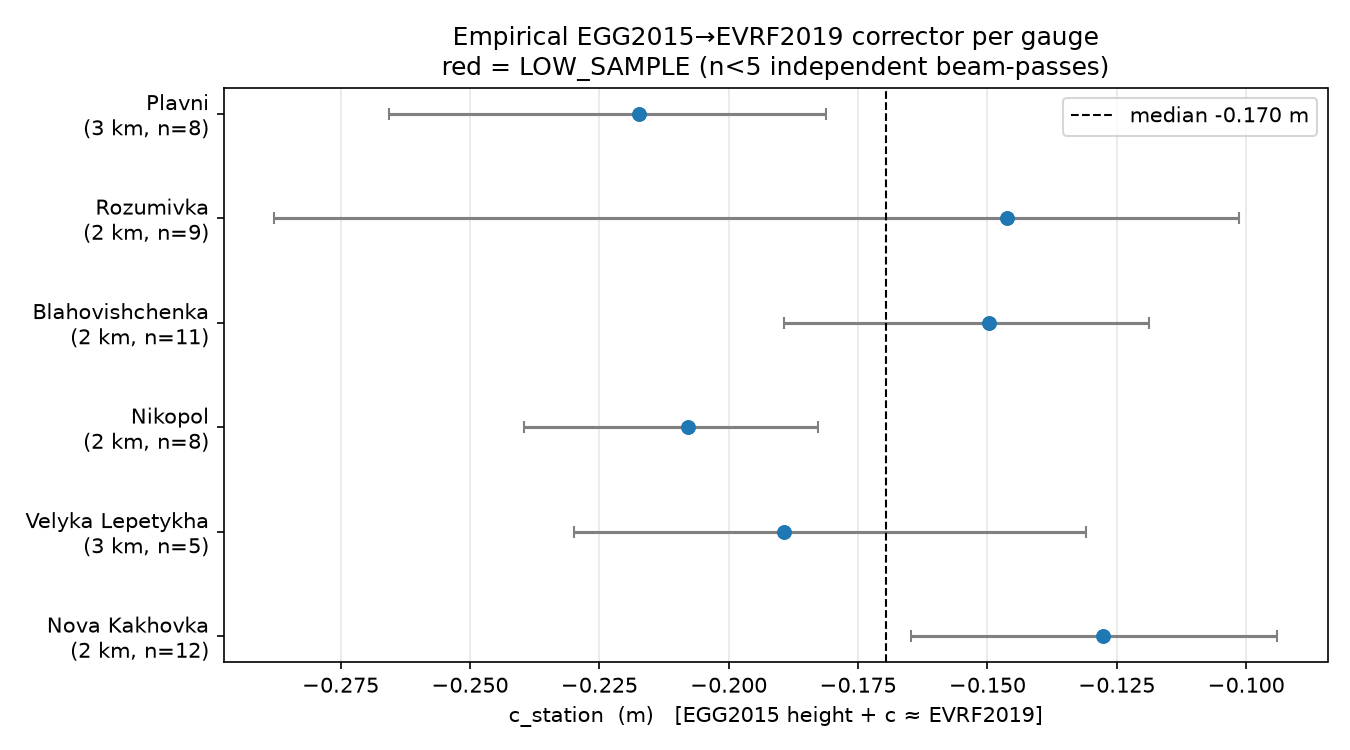

In [4]:
cols = ["name_en", "reported_radius_km", "n_matchups", "n_dates", "n_rgts",
        "delta_epsg9902_m", "c_station_m", "empirical_nmad_m",
        "bootstrap_ci95_low_m", "bootstrap_ci95_high_m",
        "c_station_B_nearest_m", "c_station_C_dailymean_m", "temporal_spread_m", "flag"]
display(by_station[cols].round(3))
from IPython.display import Image
Image(str(FIGS / "correction_by_station.png"))

## Драбина радіусів

Правило вибору звітного радіуса: **найближчий до 2 км радіус, що містить ≥5
незалежних beam-passes**. Драбина завжди публікується, щоб вибір був
аудитований. Добре вкриті радіуси стабільні до кількох см; недовкриті —
оманливі.

,name_en,radius_km,n_matchups,n_dates,c_station_m,empirical_nmad_m,bootstrap_ci95_low_m,bootstrap_ci95_high_m,flag
0,Rozumivka,0.5,1,1,-0.132,0.000,NaN,NaN,LOW_SAMPLE
1,Rozumivka,1.0,7,4,-0.143,0.032,-0.288,-0.122,OK
2,Rozumivka,2.0,9,6,-0.146,0.038,-0.288,-0.101,OK
3,Rozumivka,3.0,15,7,-0.146,0.067,-0.203,-0.125,OK
4,Rozumivka,5.0,29,10,-0.155,0.051,-0.184,-0.130,OK
5,Rozumivka,10.0,54,15,-0.139,0.067,-0.171,-0.124,OK
6,Plavni,0.5,2,1,-0.306,0.035,-0.329,-0.282,LOW_SAMPLE
7,Plavni,1.0,2,1,-0.298,0.030,-0.318,-0.278,LOW_SAMPLE
8,Plavni,2.0,2,1,-0.269,0.001,-0.270,-0.268,LOW_SAMPLE
9,Plavni,3.0,8,3,-0.217,0.060,-0.266,-0.181,OK


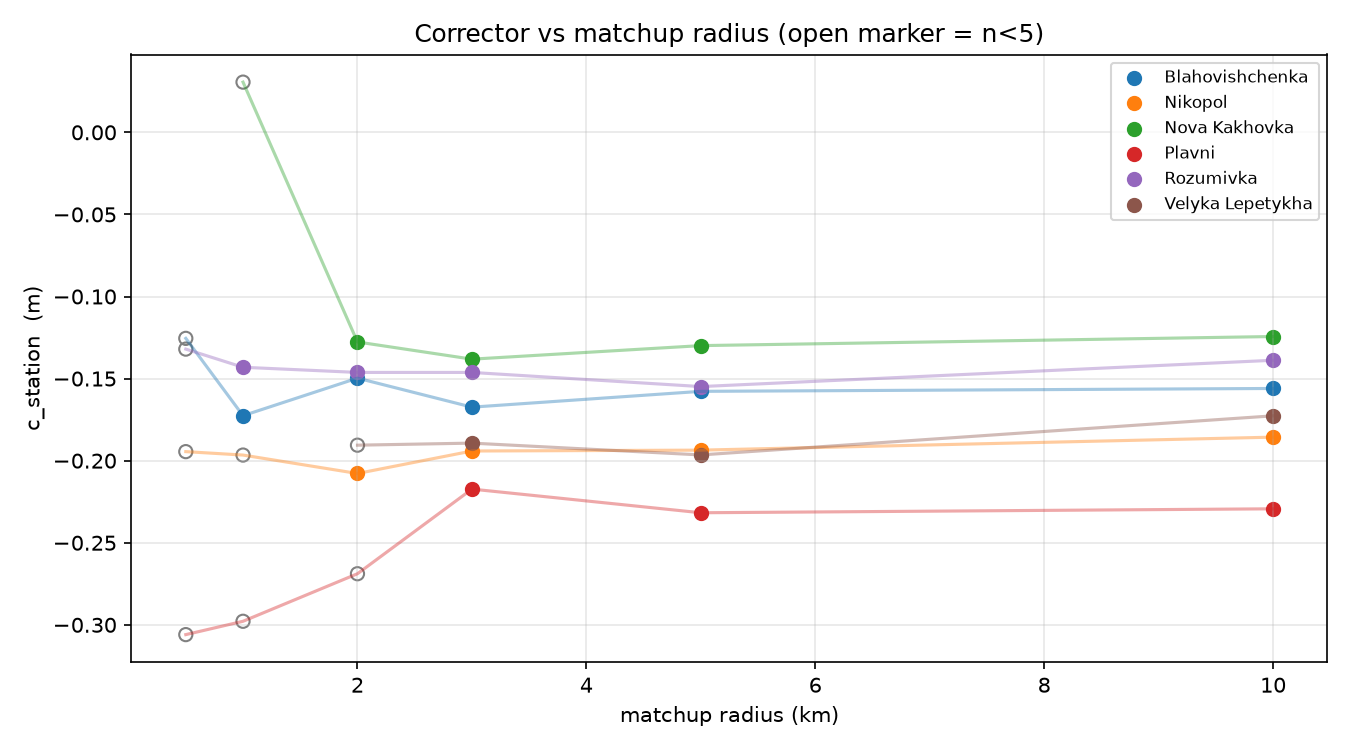

In [5]:
display(by_radius[["name_en", "radius_km", "n_matchups", "n_dates",
                   "c_station_m", "empirical_nmad_m",
                   "bootstrap_ci95_low_m", "bootstrap_ci95_high_m", "flag"]].round(3))
from IPython.display import Image
Image(str(FIGS / "correction_by_radius.png"))

## Per-RGT корректор та розкол Розумівки

`rgt_bias_m = c_{i,rgt} − c_i`. Серед добре вкритих RGT (n≥5) зсув ≤~2 см.
Розумівка бімодальна: RGT 205 (висхідний трек, читає високо біля берега) vs
RGT 989 — звідси широкий/бімодальний 2-км bootstrap CI. Рекомендована фігура
Розумівки — з рядків 3–5 км, не з 2-км пулу.

,name_en,radius_km,rgt,n_matchups,n_dates,correction_m,nmad_m,c_station_all_m,rgt_bias_m,flag
0,Rozumivka,2.0,205,4,3,-0.222,0.101,-0.146,-0.076,LOW_SAMPLE
1,Rozumivka,2.0,989,5,3,-0.128,0.027,-0.146,0.018,OK
2,Plavni,3.0,45,4,2,-0.264,0.003,-0.217,-0.047,LOW_SAMPLE
3,Plavni,3.0,645,4,1,-0.182,0.017,-0.217,0.036,LOW_SAMPLE
4,Blahovishchenka,2.0,545,4,2,-0.177,0.041,-0.150,-0.027,LOW_SAMPLE
5,Blahovishchenka,2.0,1149,7,4,-0.136,0.055,-0.150,0.014,OK
6,Nikopol,2.0,265,2,1,-0.234,0.008,-0.208,-0.026,LOW_SAMPLE
7,Nikopol,2.0,1049,6,3,-0.193,0.019,-0.208,0.015,OK
8,Velyka Lepetykha,3.0,165,3,2,-0.144,0.019,-0.189,0.045,LOW_SAMPLE
9,Velyka Lepetykha,3.0,1209,2,1,-0.220,0.014,-0.189,-0.031,LOW_SAMPLE


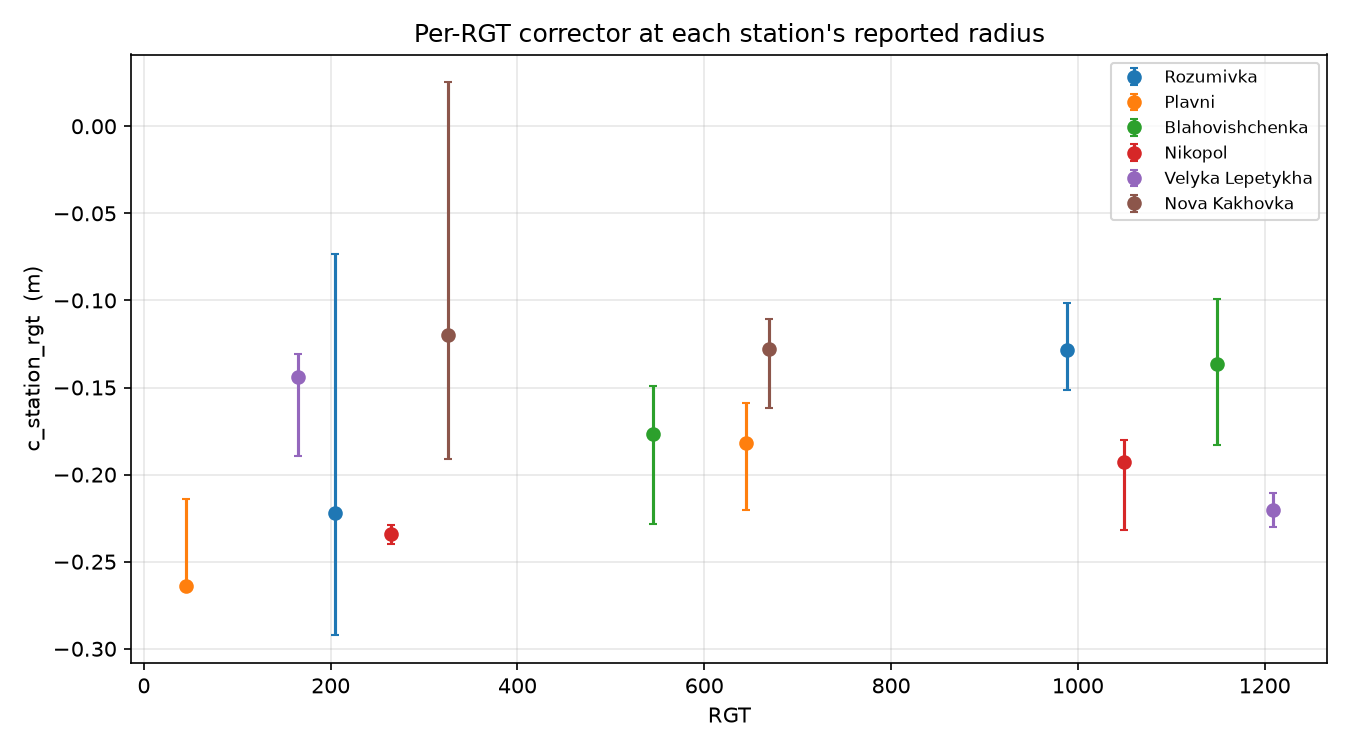

In [6]:
display(by_rgt[["name_en", "radius_km", "rgt", "n_matchups", "n_dates",
                "correction_m", "nmad_m", "c_station_all_m", "rgt_bias_m", "flag"]].round(3))
from IPython.display import Image
Image(str(FIGS / "correction_by_rgt.png"))

## Точність (precision) vs абсолютна точність (accuracy) — окремо

**PRECISION** — beam-pass NMAD і bootstrap CI медіани. Це єдина невизначеність,
яку ці дані обмежують. **ACCURACY** — обмежена окремими лініями, які **не**
підсумовуємо в квадратурі: EPSG:9902 operation accuracy 0.068 м (це поле
accuracy, **не** сигма; SD на 154 визначальних точках — 0.034 м); нуль
гідропоста (12.00 м — **прийнята** константа, не оцінюваний параметр;
округлене регіональне число, не 6 знівельованих нулів); модельна похибка EGG2015
над Україною (~0.1 м); систематичний зсув ATL13. Останні три — «не інферимо».

,station_id,name_en,reported_radius_km,n_independent_beampasses,correction_m,empirical_median_residual_m,empirical_mad_m,empirical_nmad_m,empirical_std_m,p05_m,p95_m,iqr_m,bootstrap_ci95_low_m,bootstrap_ci95_high_m,epsg9902_op_accuracy_m,sigma_gauge_zero_m,sigma_egg2015_model_m,sigma_atl13_bias_m,temporal_mismatch_spread_m,radius_ladder_spread_m,flag
0,80959,Rozumivka,2.0,9,-0.146,-0.146,0.025,0.038,0.077,-0.290,-0.085,0.036,-0.288,-0.101,0.068,not independently constrained,unresolved (not inferred from these gauges),unresolved (see rgt_bias diagnostics),0.006,0.016,OK
1,80961,Plavni,3.0,8,-0.217,-0.217,0.041,0.060,0.043,-0.266,-0.167,0.081,-0.266,-0.181,0.068,not independently constrained,unresolved (not inferred from these gauges),unresolved (see rgt_bias diagnostics),0.005,0.014,OK
2,80963,Blahovishchenka,2.0,11,-0.150,-0.150,0.033,0.049,0.044,-0.216,-0.092,0.059,-0.189,-0.119,0.068,not independently constrained,unresolved (not inferred from these gauges),unresolved (see rgt_bias diagnostics),0.008,0.023,OK
3,80964,Nikopol,2.0,8,-0.208,-0.208,0.023,0.034,0.026,-0.241,-0.179,0.041,-0.240,-0.183,0.068,not independently constrained,unresolved (not inferred from these gauges),unresolved (see rgt_bias diagnostics),0.001,0.022,OK
4,80971,Velyka Lepetykha,3.0,5,-0.189,-0.189,0.041,0.060,0.042,-0.226,-0.134,0.067,-0.230,-0.131,0.068,not independently constrained,unresolved (not inferred from these gauges),unresolved (see rgt_bias diagnostics),0.007,0.024,OK
5,80977,Nova Kakhovka,2.0,12,-0.128,-0.128,0.036,0.053,0.074,-0.189,0.023,0.061,-0.165,-0.094,0.068,not independently constrained,unresolved (not inferred from these gauges),unresolved (see rgt_bias diagnostics),0.011,0.014,OK


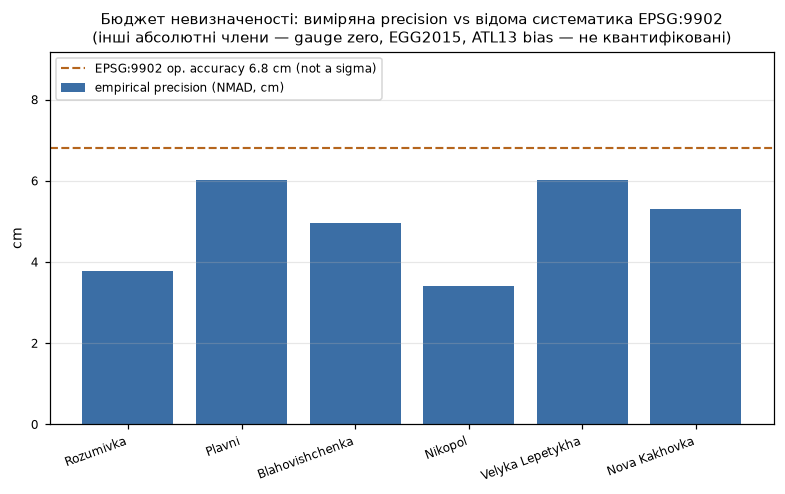

In [7]:
display(unc.round(3))

# --- figure: uncertainty budget ---
fig, ax = plt.subplots(figsize=(8.5, 4.4))
prec = unc.set_index("name_en")["empirical_nmad_m"] * 100
ax.bar(np.arange(len(prec)), prec, color="#3b6ea5", label="empirical precision (NMAD, cm)")
ax.axhline(EPSG9902_OP_ACC * 100, color="#b5651d", ls="--", lw=1.4,
           label=f"EPSG:9902 op. accuracy {EPSG9902_OP_ACC*100:.1f} cm (not a sigma)")
ax.set_xticks(np.arange(len(prec))); ax.set_xticklabels(prec.index, rotation=20, ha="right")
ax.set_ylabel("cm")
ax.set_title("Бюджет невизначеності: виміряна precision vs відома систематика EPSG:9902\n"
             "(інші абсолютні члени — gauge zero, EGG2015, ATL13 bias — не квантифіковані)")
ax.set_ylim(0, max(prec.max(), EPSG9902_OP_ACC * 100) * 1.35)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.savefig(FIGS / "uncertainty_budget.png")
plt.show()

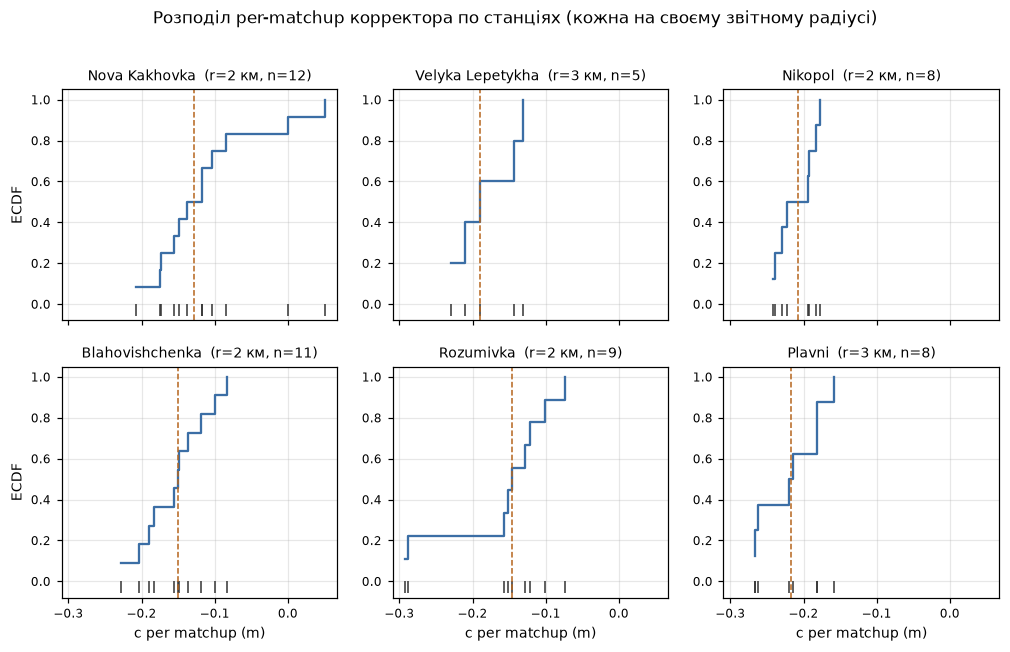

In [8]:
# --- figure: residual distributions (ECDF + rug), n is small so no bare histogram ---
# each station at ITS reported radius, not a fixed 2 km
rep_r = dict(zip(by_station["name_en"], by_station["reported_radius_km"]))
names = [n for n in by_station.sort_values("lon")["name_en"] if np.isfinite(rep_r.get(n, np.nan))]
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True)
for ax, name in zip(axes.ravel(), names):
    sub = matchups[(matchups["name_en"] == name)
                   & np.isclose(matchups["radius_km"], rep_r[name])]
    v = np.sort(sub["c_station_A_m"].dropna().to_numpy())
    if v.size:
        ax.step(v, np.arange(1, v.size + 1) / v.size, where="post", color="#3b6ea5")
        ax.plot(v, np.full_like(v, -0.03), "|", color="#333", ms=8)
        ax.axvline(np.median(v), color="#b5651d", ls="--", lw=1)
    ax.set_title(f"{name}  (r={rep_r[name]:g} км, n={v.size})", fontsize=9)
    ax.set_ylim(-0.08, 1.05); ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel("c per matchup (m)")
axes[0, 0].set_ylabel("ECDF"); axes[1, 0].set_ylabel("ECDF")
fig.suptitle("Розподіл per-matchup корректора по станціях (кожна на своєму звітному радіусі)", y=1.0)
fig.savefig(FIGS / "residual_distributions.png")
plt.show()

## Публікаційно-безпечне формулювання

> Ми оцінили **прив'язаний до гідропостів емпіричний вертикальний корректор** між
> висотами водної поверхні ICESat-2 ATL13, зведеними через EGG2015, і рівнями
> гідропостів, трансформованими з BS-77 у EVRF2019 через EPSG:9902. Корректор
> призначений для локальної гармонізації ланцюга ATL13+EGG2015 і **не є**
> офіційною трансформацією датумів чи незалежним визначенням квазігеоїда.

> *We estimated a gauge-constrained empirical vertical correction between ICESat-2
> ATL13 water-surface elevations reduced with EGG2015 and gauge water levels
> transformed from BS77 to EVRF2019 using EPSG:9902. The correction is intended
> for local harmonization of the ATL13+EGG2015 observation chain and is not
> interpreted as an official datum transformation or an independent quasigeoid
> determination.*

Фраза «regional correction = −0.17 ± 0.05 m» допустима **лише** якщо ±0.05 м
явно позначено як *empirical spatial/repeatability scale*, а не абсолютна
точність EVRF2019.